In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pickle

print("Imports successful")

Imports successful


In [3]:
train_df = pd.read_csv('../data/train_clean.csv')
test_df = pd.read_csv('../data/test_clean.csv')

# Drop any rows where clean_text is NaN
train_df = train_df.dropna(subset=['clean_text'])
test_df = test_df.dropna(subset=['clean_text'])

print(f"Train: {len(train_df)} rows")
print(f"Test:  {len(test_df)} rows")

Train: 25000 rows
Test:  25000 rows


In [4]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test  = test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (25000, 10000)
X_test shape:  (25000, 10000)


In [5]:
print("Training model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("Done")

Training model...
Done


In [6]:
y_pred = lr_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 88.5 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



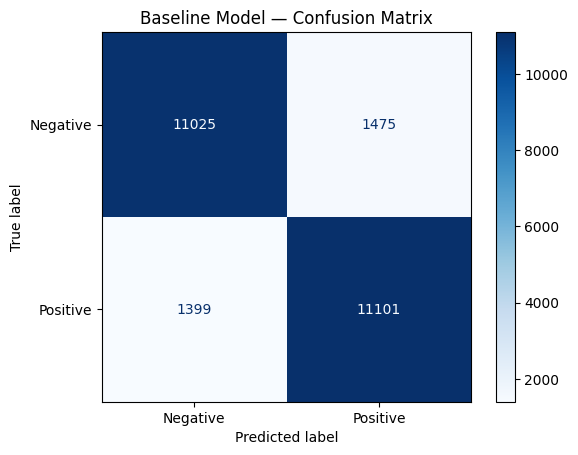

Saved to outputs/


In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Baseline Model — Confusion Matrix')
plt.savefig('../outputs/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

In [8]:
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("Model and vectorizer saved to models/")

Model and vectorizer saved to models/
